In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# **1. Load preprocessed datasets**

In [2]:
X_train = pd.read_csv('X_train_balanced.csv')
y_train = pd.read_csv('y_train_balanced.csv').values.ravel() # Flatten to 1D array

X_val = pd.read_csv('X_val.csv')
y_val = pd.read_csv('y_val.csv').values.ravel()

X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv').values.ravel()

In [3]:
print("Data loaded successfully.")

print(f"Training shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

Data loaded successfully.
Training shape: (128100, 11)
Validation shape: (15000, 11)
Test shape: (15000, 11)


In [4]:
X_train.head(10)

,HbA1c_level,blood_glucose_level,age,bmi,hypertension,heart_disease,smoking_history_former,smoking_history_never,smoking_history_current,gender_Female,smoking_history_unknown
0,-1.454207,-0.972727,0.623757,2.025021,0,1,0.0,1.0,0.0,1.0,0.0
1,1.029762,-1.233014,0.978816,0.058825,0,0,1.0,0.0,0.0,0.0,0.0
2,0.456538,2.671292,0.313080,2.025021,0,0,0.0,1.0,0.0,0.0,0.0
3,-0.689909,-1.363157,1.156345,0.058825,0,0,0.0,0.0,0.0,0.0,1.0
4,0.169927,0.198565,0.890051,0.645064,0,0,1.0,0.0,0.0,0.0,0.0
5,-0.976520,0.198565,-0.086361,1.630369,0,0,0.0,0.0,1.0,1.0,0.0
6,-0.976520,0.068421,0.490610,1.383160,0,0,0.0,1.0,0.0,1.0,0.0
7,-1.931893,1.630144,1.378257,0.565604,0,1,0.0,1.0,0.0,0.0,0.0
8,1.029762,0.068421,0.091169,0.058825,0,0,0.0,1.0,0.0,0.0,0.0
9,-1.454207,-0.191866,-1.417832,0.058825,0,0,0.0,0.0,0.0,1.0,1.0


# **2. Train and Validate the Model**

In [5]:
# Create a dictionary of models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "K-Neighbors": KNeighborsClassifier(),
    "Gaussian NB": GaussianNB(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1)
}

In [6]:
results = []

print("Training and validating models...")

for name, model in models.items():
    print(f"Training {name}...")

    # Train
    model.fit(X_train, y_train)

    # Validate (Manual Validation)
    y_val_pred = model.predict(X_val)

    # Get probabilities for ROC-AUC (if supported)
    if hasattr(model, "predict_proba"):
        y_val_prob = model.predict_proba(X_val)[:, 1]
    else:
        y_val_prob = model.decision_function(X_val)

    # Calculate metrics
    accuracy = accuracy_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred)
    recall = recall_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)
    roc = roc_auc_score(y_val, y_val_prob)

    results.append({
        "Model": name,
        "Validation Accuracy": accuracy,
        "Validation Precision": precision,
        "Validation Recall": recall,
        "Validation F1 Score": f1,
        "Validation ROC-AUC": roc
    })

print("Training complete.")

Training and validating models...
Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training K-Neighbors...
Training Gaussian NB...
Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:57:22] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training LightGBM...
Training complete.


# **3. Compare Models to Find the Best One**


Model Performance on Validation Set (Sorted by ROC-AUC):


,Model,Validation Accuracy,Validation Precision,Validation Recall,Validation F1 Score,Validation ROC-AUC
7,LightGBM,0.970467,0.916834,0.717647,0.805103,0.979052
6,XGBoost,0.969400,0.897661,0.722353,0.800522,0.978008
3,Gradient Boosting,0.953867,0.702571,0.792941,0.745026,0.977870
2,Random Forest,0.959400,0.765127,0.753725,0.759384,0.967889
0,Logistic Regression,0.887867,0.423754,0.887059,0.573529,0.963201
4,K-Neighbors,0.916333,0.504907,0.807059,0.621189,0.919540
5,Gaussian NB,0.872800,0.383253,0.814902,0.521325,0.917877
1,Decision Tree,0.948067,0.673913,0.753725,0.711588,0.860907


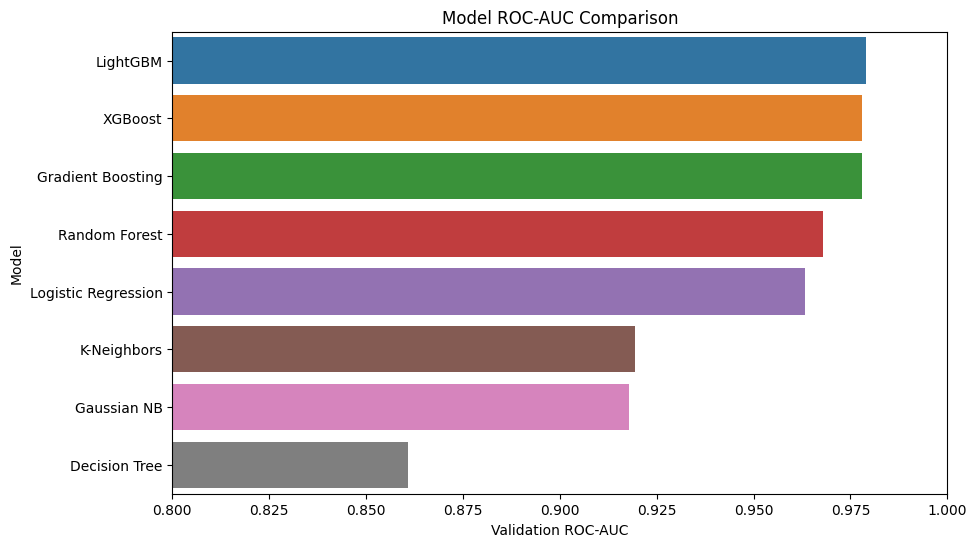

In [7]:
# Create a DataFrame to compare after validating
val_results_df = pd.DataFrame(results, columns=["Model", "Validation Accuracy", "Validation Precision", "Validation Recall", "Validation F1 Score", "Validation ROC-AUC"])
val_results_df = val_results_df.sort_values(by="Validation ROC-AUC", ascending=False) # Sorting by Recall because missing a sick person is dangerous

# Show the table
print("\nModel Performance on Validation Set (Sorted by ROC-AUC):")
display(val_results_df)

# Visualize recall scores
plt.figure(figsize=(10, 6))
sns.barplot(x="Validation ROC-AUC", y="Model", data=val_results_df, hue="Model")
plt.title("Model ROC-AUC Comparison")
plt.xlim(0.8, 1.0) # Zoom in to see differences better
plt.show()

# **4. Predict all the trained models**

In [8]:
# Select the best model automatically
best_model_name = val_results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print(f"Best Model Selected: {best_model_name}")


Best Model Selected: LightGBM


In [9]:
# Predict on TEST set
y_test_pred = best_model.predict(X_test)
y_test_prob = best_model.predict_proba(X_test)[:, 1]

# **5. Performance evaluation of each model**

In [14]:
all_test_results = []

print("Evaluating all models on the test set...")

for name, model in models.items():
  print(f"Evaluating {name} on test set...")

  y_test_pred = model.predict(X_test)

  if hasattr(model, "predict_proba"):
    y_test_prob = model.predict_proba(X_test)[:, 1]
  else:
    y_test_prob = model.decision_function(X_test)

  accuracy = accuracy_score(y_test, y_test_pred)
  precision = precision_score(y_test, y_test_pred)
  recall = recall_score(y_test, y_test_pred)
  f1 = f1_score(y_test, y_test_pred)
  roc = roc_auc_score(y_test, y_test_prob)

  all_test_results.append({
      "Model": name,
      "Test Accuracy": accuracy,
      "Test Precision": precision,
      "Test Recall": recall,
      "Test F1 Score": f1,
      "Test ROC-AUC": roc
  })

test_results_df = pd.DataFrame(all_test_results)

Evaluating all models on the test set...
Evaluating Logistic Regression on test set...
Evaluating Decision Tree on test set...
Evaluating Random Forest on test set...
Evaluating Gradient Boosting on test set...
Evaluating K-Neighbors on test set...
Evaluating Gaussian NB on test set...
Evaluating XGBoost on test set...
Evaluating LightGBM on test set...



Model Performance on Test Set (Sorted by ROC-AUC):


,Model,Test Accuracy,Test Precision,Test Recall,Test F1 Score,Test ROC-AUC
7,LightGBM,0.971067,0.940314,0.704314,0.805381,0.977927
6,XGBoost,0.969867,0.912738,0.713725,0.801056,0.976534
3,Gradient Boosting,0.951933,0.692897,0.780392,0.734046,0.974233
2,Random Forest,0.957733,0.760357,0.734118,0.747007,0.964816
0,Logistic Regression,0.886400,0.419331,0.874510,0.566853,0.959507
5,Gaussian NB,0.876067,0.388037,0.793725,0.521246,0.915701
4,K-Neighbors,0.912667,0.491558,0.799216,0.608722,0.912843
1,Decision Tree,0.951133,0.699558,0.745098,0.721610,0.859735


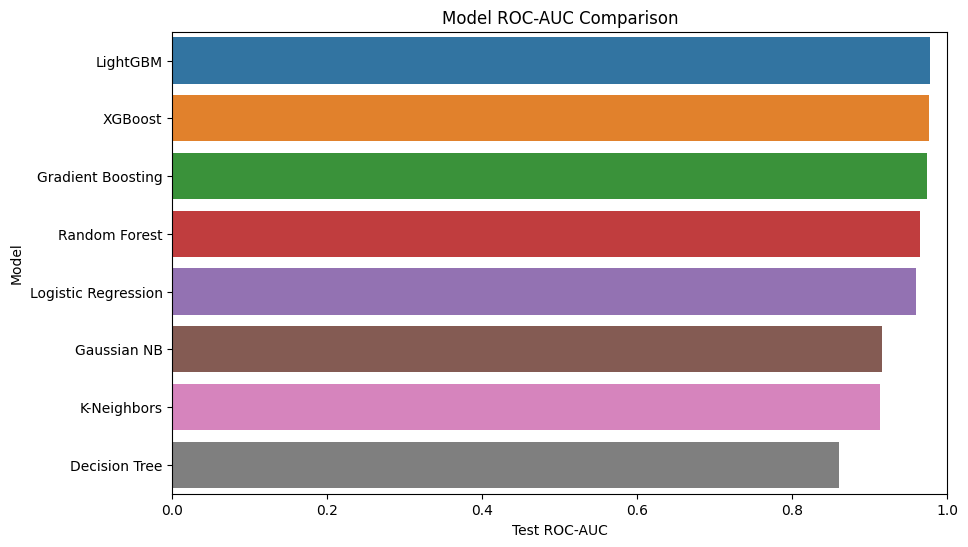

In [15]:
# Create a DataFrame to compare after validating
test_results_df = pd.DataFrame(all_test_results, columns=["Model", "Test Accuracy", "Test Precision", "Test Recall", "Test F1 Score", "Test ROC-AUC"])
test_results_df = test_results_df.sort_values(by="Test ROC-AUC", ascending=False)

# Show the table
print("\nModel Performance on Test Set (Sorted by ROC-AUC):")
display(test_results_df)

# Visualize recall scores
plt.figure(figsize=(10, 6))
sns.barplot(x="Test ROC-AUC", y="Model", data=test_results_df, hue="Model")
plt.title("Model ROC-AUC Comparison")
plt.xlim(0.0, 1.0) # Zoom in to see differences better
plt.show()

# **6. Generate a confusion matrix for each model**

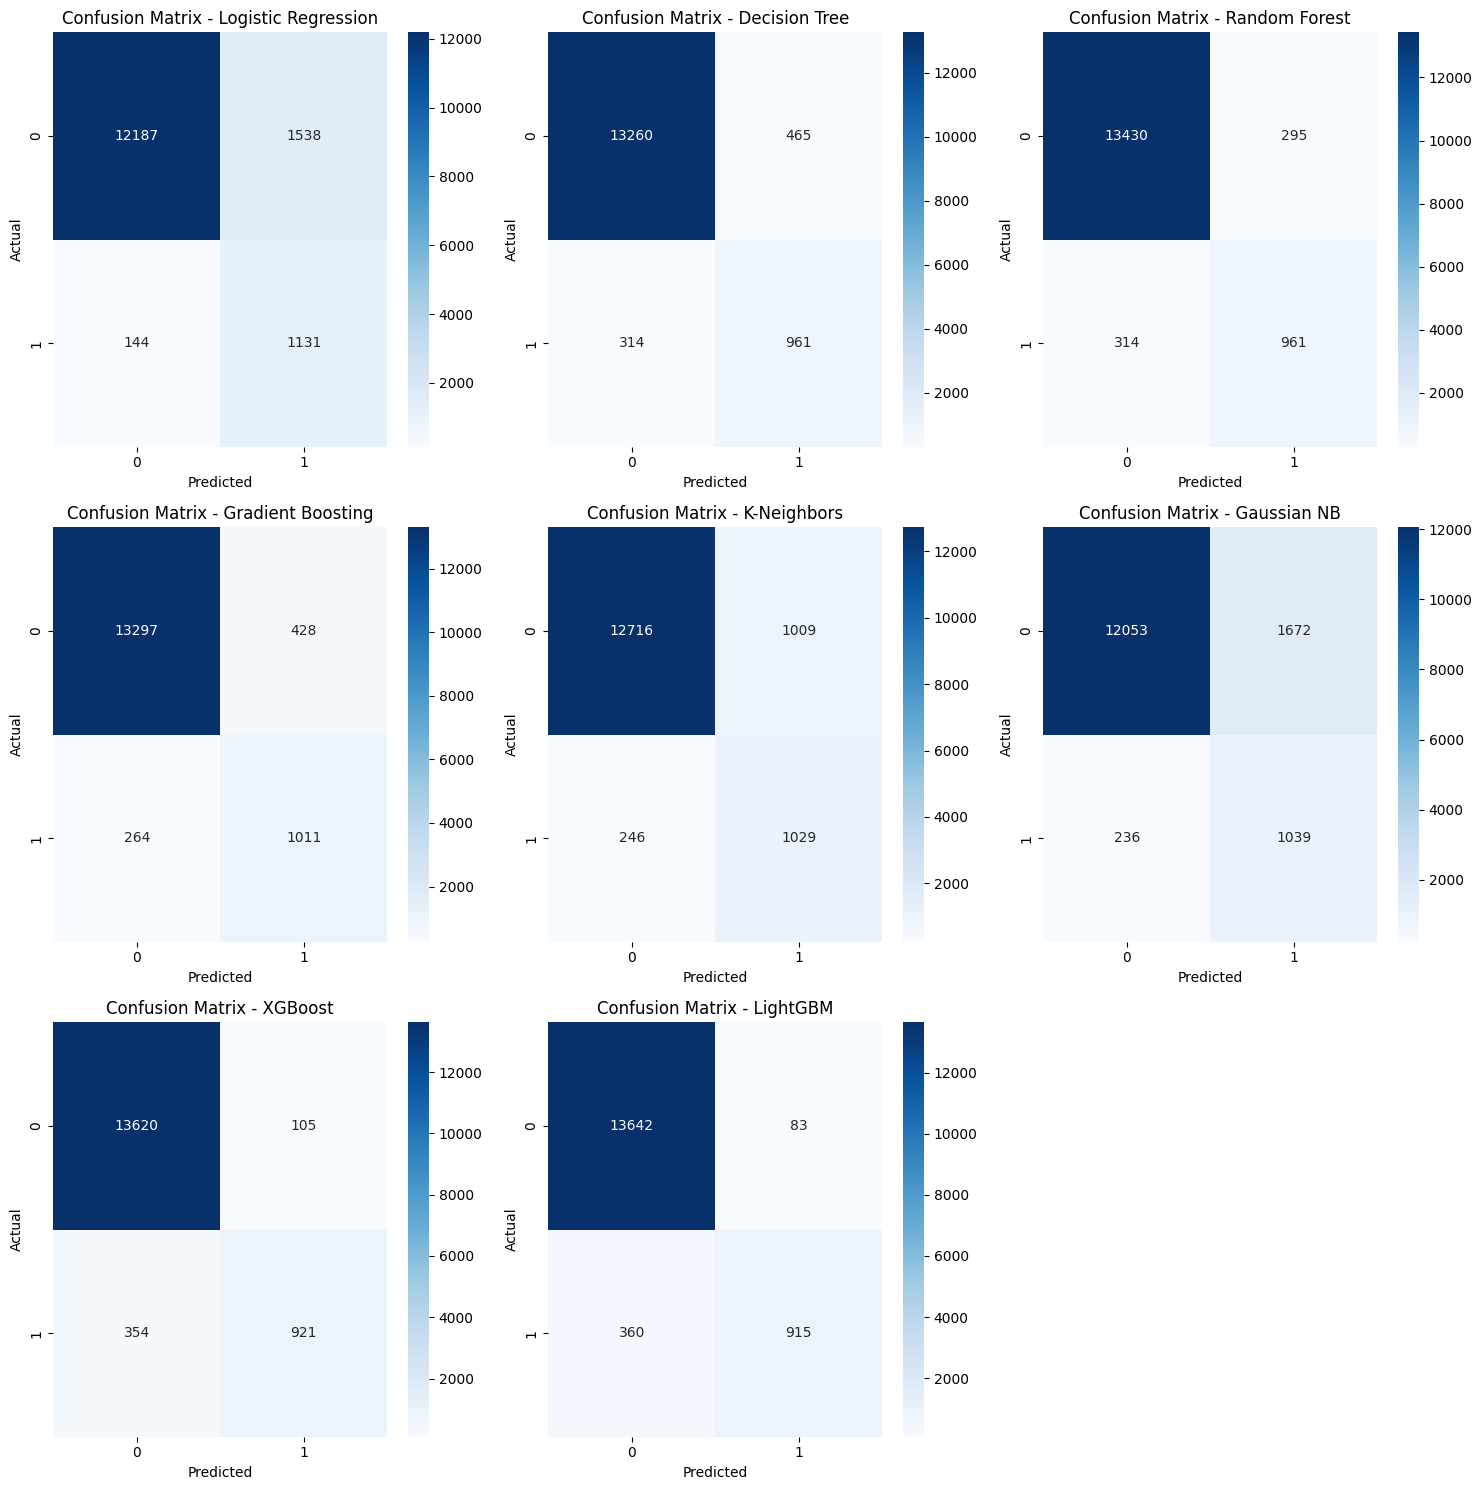

In [16]:
n_models = len(models)
cols = 3
rows = (n_models + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    # Make predictions on the validation set
    y_val_pred = model.predict(X_val)

    # Plot Confusion Matrix for this model
    cm = confusion_matrix(y_val, y_val_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'Confusion Matrix - {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# **7. Save the best model**

**LightGBM** is the best overall model. It has the highest scores across all metrics, especially the F1-Score (which balances Precision and Recall). This makes it the most reliable choice.

In [17]:
# Save the best model
filename = f'best_diabetes_model_{best_model_name.replace(" ", "_")}.pkl'
joblib.dump(best_model, filename)

print(f"Best model saved as {filename}")

Best model saved as best_diabetes_model_LightGBM.pkl
